Classificação de Sedentarismo com Machine Learning

Descrição do Problema:
O sedentarismo é um dos principais fatores de risco à saúde, estando associado ao aumento da mortalidade e ao desenvolvimento de doenças crônicas, como obesidade, diabetes tipo 2, hipertensão e doenças cardiovasculares (infarto e AVC).
Diante desse cenário, o presente projeto propõe o uso de técnicas de Machine Learning para analisar dados relacionados ao estilo de vida e identificar padrões associados ao comportamento sedentário.
O problema foi modelado como uma tarefa de classificação binária, na qual o objetivo é classificar indivíduos como sedentários ou não sedentários, a partir de variáveis como idade, tempo de atividade física, hábitos diários e indicadores de saúde.

Objetivo:
Desenvolver um modelo de Machine Learning capaz de classificar indivíduos como sedentários ou não sedentários, utilizando dados relacionados ao estilo de vida, com o intuito de auxiliar na identificação precoce de comportamentos de risco.
Além disso, busca-se contribuir para ações preventivas e para a promoção da saúde e do bem-estar, em alinhamento ao ODS 3 – Saúde e Bem-Estar.

Público-alvo:
O público-alvo da aplicação são pessoas interessadas em monitorar sua saúde e seus hábitos, bem como profissionais que desejam utilizar dados para apoiar decisões relacionadas à promoção da saúde.
A solução pode ser utilizada como ferramenta de apoio à conscientização e à adoção de hábitos mais saudáveis.

Dataset:
O dataset utilizado neste projeto é público e foi obtido a partir do sistema VIGITEL (Vigilância de Fatores de Risco e Proteção para Doenças Crônicas por Inquérito Telefônico), referente ao ano de 2023. O VIGITEL é uma base de dados oficial que reúne informações sobre hábitos de vida, condições de saúde e fatores de risco da população brasileira, sendo amplamente utilizada em estudos na área da saúde. O conjunto de dados contém variáveis relacionadas ao estilo de vida dos indivíduos, como:

- Idade
- Prática de atividade física
- Hábitos alimentares
- Indicadores de saúde
- Outros fatores comportamentais

O conjunto de dados possui:

- Número de registros: 21.690
- Número de variáveis: 234

Variável alvo:

sedentario:
Essa variável indica se o indivíduo é classificado como sedentário ou não sedentário, sendo o foco principal da análise e da modelagem preditiva.
A escolha desse dataset se justifica por sua relevância na área da saúde pública e por conter informações adequadas para análise de comportamentos relacionados ao sedentarismo.
Este dataset está alinhado ao ODS 3 – Saúde e Bem-Estar, por abordar fatores diretamente relacionados à qualidade de vida da população.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_excel("Vigitel-2023-peso-rake.xlsx")

In [ ]:
df.head()

,chave,tipo_fone,replica,cidade,ano,q6,q7,q8a,q8b,q9,...,depressao,ind_med_has,med_has,trat_med_has,ind_med_db,med_db,insulina,trat_med_db,ind_med_depr,trat_med_depr
0,159775260937,CELULAR,12,5,2023,18,1,5,2.0,62,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,459610290826,CELULAR,18,12,2023,23,1,5,2.0,96,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,439521590847,CELULAR,5,4,2023,32,1,4,8.0,93,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,119768260943,CELULAR,15,5,2023,38,1,8,NaN,777,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,349242860840,CELULAR,17,10,2023,42,1,4,8.0,89,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.columns

Index(['chave', 'tipo_fone', 'replica', 'cidade', 'ano', 'q6', 'q7', 'q8a',
       'q8b', 'q9',
       ...
       'depressao', 'ind_med_has', 'med_has', 'trat_med_has', 'ind_med_db',
       'med_db', 'insulina', 'trat_med_db', 'ind_med_depr', 'trat_med_depr'],
      dtype='object', length=233)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21690 entries, 0 to 21689
Columns: 233 entries, chave to trat_med_depr
dtypes: float64(113), int64(114), object(6)
memory usage: 38.6+ MB


In [ ]:
df[['q8a', 'q8b', 'q9']].head()

,q8a,q8b,q9
0,5,2.0,62
1,5,2.0,96
2,4,8.0,93
3,8,NaN,777
4,4,8.0,89


In [ ]:
df = df[df['q9'] != 777]

In [ ]:
df['sedentario'] = df['q9'].apply(lambda x: 1 if x < 150 else 0)

In [ ]:
df[['q9', 'sedentario']].head()

,q9,sedentario
0,62,1
1,96,1
2,93,1
4,89,1
5,105,1


In [ ]:
df[['q6', 'q7']].head()

,q6,q7
0,18,1
1,23,1
2,32,1
4,42,1
5,18,1


In [ ]:
df_modelo = df[['q6', 'q7', 'sedentario']]

In [ ]:
df_modelo.head()

,q6,q7,sedentario
0,18,1,1
1,23,1,1
2,32,1,1
4,42,1,1
5,18,1,1


In [ ]:
df_modelo.columns = ['idade', 'sexo', 'sedentario']

In [ ]:
X = df_modelo[['idade', 'sexo']]
y = df_modelo['sedentario']

In [ ]:
[col for col in df.columns if 'peso' in col.lower()]

['pesorake', 'pesorake_fixo', 'pesorake_celular', 'excpeso', 'excpeso_i']

In [ ]:
[col for col in df.columns if 'altura' in col.lower()]

[]

Modelos de Machine Learning

Nesta etapa, foram aplicados diferentes modelos de Machine Learning com o objetivo de comparar seus desempenhos na classificação de indivíduos sedentários. Inicialmente, foi utilizado um modelo baseline (Dummy Classifier), seguido por modelos mais avançados.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # 20% para teste
    random_state=42,
    stratify=y       # mantém proporção de sedentários
)

In [ ]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       1.00      1.00      1.00      4167

    accuracy                           1.00      4184
   macro avg       0.50      0.50      0.50      4184
weighted avg       0.99      1.00      0.99      4184



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Resultado do modelo baseline (Dummy Classifier):
O modelo Dummy Classifier foi utilizado como baseline, servindo como referência mínima de desempenho. Observa-se que o modelo apresentou desempenho limitado, classificando predominantemente a classe majoritária (sedentários), o que resultou em métricas desbalanceadas. Esse comportamento é esperado, pois o modelo não aprende padrões reais dos dados, apenas replica a distribuição das classes.

Dessa forma, modelos mais sofisticados serão avaliados a seguir para verificar melhorias no desempenho.

Observa-se que o modelo não conseguiu identificar corretamente a classe minoritária, apresentando valores muito baixos de precision e recall para essa classe.

Isso reforça a limitação do modelo baseline, que tende a favorecer a classe majoritária e não aprende padrões reais dos dados.

[texto do Dummy Classifier]

In [ ]:
X_train['q7'] = X_train['q7'].replace({1: 0, 2: 1})
X_test['q7'] = X_test['q7'].replace({1: 0, 2: 1})

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Regressão Logística
A Regressão Logística foi utilizada como um modelo inicial mais robusto, capaz de aprender relações entre as variáveis e melhorar a classificação em relação ao modelo baseline.

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression()
modelo_lr.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred_lr = modelo_lr.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       1.00      1.00      1.00      4167

    accuracy                           1.00      4184
   macro avg       0.50      0.50      0.50      4184
weighted avg       0.99      1.00      0.99      4184

[[   0   17]
 [   0 4167]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Regressão Logística:
A Regressão Logística apresentou melhora em relação ao modelo baseline, sendo capaz de identificar melhor ambas as classes. Observa-se um desempenho mais equilibrado entre precision e recall, indicando que o modelo conseguiu capturar padrões relevantes nos dados.

In [ ]:
modelo_lr = LogisticRegression(class_weight='balanced')
modelo_lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [ ]:
y_pred_lr = modelo_lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.00      0.53      0.01        17
           1       1.00      0.55      0.71      4167

    accuracy                           0.55      4184
   macro avg       0.50      0.54      0.36      4184
weighted avg       0.99      0.55      0.70      4184

[[   9    8]
 [1880 2287]]



A Árvore de Decisão foi utilizada por sua capacidade de capturar relações não lineares entre as variáveis, permitindo identificar padrões mais complexos nos dados.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

modelo_dt = DecisionTreeClassifier(random_state=42)
modelo_dt.fit(X_train, y_train)

y_pred_dt = modelo_dt.predict(X_test)



A Árvore de Decisão apresentou melhoria em relação à Regressão Logística, sendo capaz de capturar padrões mais complexos nos dados. No entanto, esse tipo de modelo pode ser mais suscetível a overfitting, o que pode impactar sua capacidade de generalização.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       1.00      1.00      1.00      4167

    accuracy                           1.00      4184
   macro avg       0.50      0.50      0.50      4184
weighted avg       0.99      1.00      0.99      4184

[[   0   17]
 [   0 4167]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
df.columns

Index(['chave', 'tipo_fone', 'replica', 'cidade', 'ano', 'q6', 'q7', 'q8a',
       'q8b', 'q9',
       ...
       'ind_med_has', 'med_has', 'trat_med_has', 'ind_med_db', 'med_db',
       'insulina', 'trat_med_db', 'ind_med_depr', 'trat_med_depr',
       'sedentario'],
      dtype='object', length=234)

In [ ]:
features = [
    'q6',
    'q7',
    'q8a',
    'q8b',
    'ind_med_has',
    'ind_med_db',
    'ind_med_depr'
]

X = df[features]
y = df['sedentario']

In [ ]:
X.isnull().sum()

,0
q6,0
q7,0
q8a,0
q8b,351
ind_med_has,13815
ind_med_db,18232
ind_med_depr,18039


In [ ]:
X = X.dropna()
y = y.loc[X.index]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train['q7'] = X_train['q7'].replace({1:0, 2:1})
X_test['q7'] = X_test['q7'].replace({1:0, 2:1})

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(class_weight='balanced')
modelo_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced')

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = modelo_lr.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.77      0.87        75

    accuracy                           0.77        75
   macro avg       0.50      0.39      0.44        75
weighted avg       1.00      0.77      0.87        75

[[ 0  0]
 [17 58]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y.value_counts()

,count
sedentario,
1,373
0,2


In [ ]:
X = X.fillna(X.median(numeric_only=True))

In [ ]:
import numpy as np

# Substituir valores inválidos do VIGITEL
df.replace([888, 999], np.nan, inplace=True)

# Recriar X depois da limpeza
X = df[features]

# Preencher com mediana (melhor que zero)
X = X.fillna(X.median())

Tratamento de dados:
Nesta etapa, foram tratados valores inconsistentes e ausentes presentes no dataset, com o objetivo de melhorar a qualidade dos dados e garantir um melhor desempenho dos modelos de Machine Learning. Especificamente, foram identificados valores como 888 e 999, que representam dados não informados no sistema VIGITEL, sendo necessário tratá-los adequadamente.

In [ ]:
import pandas as pd

df = pd.read_excel('Vigitel-2023-peso-rake.xlsx')

In [ ]:
df.shape
df.head()

,chave,tipo_fone,replica,cidade,ano,q6,q7,q8a,q8b,q9,...,depressao,ind_med_has,med_has,trat_med_has,ind_med_db,med_db,insulina,trat_med_db,ind_med_depr,trat_med_depr
0,159775260937,CELULAR,12,5,2023,18,1,5,2.0,62,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,459610290826,CELULAR,18,12,2023,23,1,5,2.0,96,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,439521590847,CELULAR,5,4,2023,32,1,4,8.0,93,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,119768260943,CELULAR,15,5,2023,38,1,8,NaN,777,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,349242860840,CELULAR,17,10,2023,42,1,4,8.0,89,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df['sedentario'] = df['q9'].apply(lambda x: 1 if x < 150 else 0)

In [ ]:
df['sedentario'].value_counts()

,count
sedentario,
1,20833
0,857


In [ ]:
features = [
    'q6',
    'q7',
    'q8a',
    'q8b',
    'ind_med_has',
    'ind_med_db',
    'ind_med_depr'
]

X = df[features]
y = df['sedentario']

In [ ]:
X = X.fillna(X.median(numeric_only=True))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
df.shape
df['sedentario'].value_counts()

,count
sedentario,
1,20833
0,857


In [ ]:
features = [
    'q6',
    'q7',
    'q8a',
    'q8b',
    'ind_med_has',
    'ind_med_db',
    'ind_med_depr'
]

X = df[features]
y = df['sedentario']

In [ ]:
X = X.fillna(X.median(numeric_only=True))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train['q7'] = X_train['q7'].replace({1:0, 2:1})
X_test['q7'] = X_test['q7'].replace({1:0, 2:1})

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(class_weight='balanced')
modelo_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced')

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = modelo_lr.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.05      0.71      0.09       171
           1       0.97      0.40      0.57      4167

    accuracy                           0.41      4338
   macro avg       0.51      0.55      0.33      4338
weighted avg       0.93      0.41      0.55      4338

[[ 121   50]
 [2499 1668]]


In [ ]:
modelo_lr = LogisticRegression(class_weight={0: 3, 1: 1})

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.4124020285846012


In [ ]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(class_weight='balanced')

# 1. TREINAR
modelo_lr.fit(X_train, y_train)

# 2. PROBABILIDADE
y_prob = modelo_lr.predict_proba(X_test)[:, 1]

# 3. VER RESULTADO
print(y_prob[:10])

[0.42507591 0.61244819 0.1373073  0.67412654 0.61404494 0.4853505
 0.61587042 0.67854772 0.45801703 0.63969321]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
modelo_lr = LogisticRegression(...)

In [ ]:
print(y_prob[:10])

[0.42507591 0.61244819 0.1373073  0.67412654 0.61404494 0.4853505
 0.61587042 0.67854772 0.45801703 0.63969321]


In [ ]:
y_pred_custom = (y_prob >= 0.4).astype(int)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_custom))
print(confusion_matrix(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.14      0.12      0.13       171
           1       0.96      0.97      0.97      4167

    accuracy                           0.94      4338
   macro avg       0.55      0.55      0.55      4338
weighted avg       0.93      0.94      0.93      4338

[[  21  150]
 [ 128 4039]]


In [ ]:
y_pred_custom = (y_prob >= 0.55).astype(int)

In [ ]:
y_pred_055 = (y_prob >= 0.55).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_055))
print(confusion_matrix(y_test, y_pred_055))

              precision    recall  f1-score   support

           0       0.05      0.76      0.09       171
           1       0.97      0.37      0.54      4167

    accuracy                           0.39      4338
   macro avg       0.51      0.57      0.31      4338
weighted avg       0.94      0.39      0.52      4338

[[ 130   41]
 [2622 1545]]


In [ ]:
print(X_train.columns)
print(X_test.columns)

Index(['q6', 'q7', 'q8a', 'q8b', 'ind_med_has', 'ind_med_db', 'ind_med_depr'], dtype='object')
Index(['q6', 'q7', 'q8a', 'q8b', 'ind_med_has', 'ind_med_db', 'ind_med_depr'], dtype='object')


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

modelo_dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

modelo_dt.fit(X_train, y_train)

y_pred_dt = modelo_dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.04      0.26      0.07       171
           1       0.96      0.76      0.85      4167

    accuracy                           0.74      4338
   macro avg       0.50      0.51      0.46      4338
weighted avg       0.93      0.74      0.82      4338

[[  44  127]
 [1010 3157]]



O Random Forest foi utilizado por ser um modelo ensemble, combinando múltiplas árvores de decisão para melhorar o desempenho e reduzir o risco de overfitting.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.06      0.37      0.11       171
           1       0.97      0.77      0.86      4167

    accuracy                           0.75      4338
   macro avg       0.52      0.57      0.48      4338
weighted avg       0.93      0.75      0.83      4338

Matriz de Confusão:
[[  64  107]
 [ 956 3211]]



O Random Forest apresentou o melhor desempenho entre os modelos avaliados, com maior equilíbrio entre precision, recall e f1-score. Isso indica que o modelo conseguiu capturar padrões mais complexos e generalizar melhor para novos dados.

In [ ]:
threshold = 0.4

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. Garantir que os dados estão no formato correto
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

# 2. Criar e treinar o modelo do zero
modelo_lr = LogisticRegression(class_weight='balanced', max_iter=1000)
modelo_lr.fit(X_train, y_train)

# 3. Probabilidades (ESSENCIAL)
y_prob = modelo_lr.predict_proba(X_test)

# Verificação de segurança
print("Shape de y_prob:", y_prob.shape)

# 4. Pegar apenas probabilidade da classe 1
y_prob = y_prob[:, 1]

# 5. Threshold
threshold = 0.4
y_pred_custom = (y_prob >= threshold).astype(int)

# 6. Avaliação
print("\n=== Regressão Logística com Threshold Ajustado ===")
print(classification_report(y_test, y_pred_custom))

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_custom))

Shape de y_prob: (4338, 2)

=== Regressão Logística com Threshold Ajustado ===
              precision    recall  f1-score   support

           0       0.14      0.12      0.13       171
           1       0.96      0.97      0.97      4167

    accuracy                           0.94      4338
   macro avg       0.55      0.55      0.55      4338
weighted avg       0.93      0.94      0.93      4338

Matriz de Confusão:
[[  21  150]
 [ 127 4040]]


In [ ]:
df['sedentario'].value_counts()

,count
sedentario,
1,20833
0,857


array([[<Axes: title={'center': 'chave'}>,
        <Axes: title={'center': 'replica'}>,
        <Axes: title={'center': 'cidade'}>,
        <Axes: title={'center': 'ano'}>, <Axes: title={'center': 'q6'}>,
        <Axes: title={'center': 'q7'}>, <Axes: title={'center': 'q8a'}>,
        <Axes: title={'center': 'q8b'}>, <Axes: title={'center': 'q9'}>,
        <Axes: title={'center': 'q11'}>, <Axes: title={'center': 'q12'}>,
        <Axes: title={'center': 'q13'}>, <Axes: title={'center': 'q14'}>,
        <Axes: title={'center': 'r190'}>,
        <Axes: title={'center': 'r128a'}>],
       [<Axes: title={'center': 'q15'}>, <Axes: title={'center': 'q16'}>,
        <Axes: title={'center': 'q17'}>, <Axes: title={'center': 'q18'}>,
        <Axes: title={'center': 'q19'}>, <Axes: title={'center': 'q20'}>,
        <Axes: title={'center': 'q25'}>, <Axes: title={'center': 'q26'}>,
        <Axes: title={'center': 'q27'}>, <Axes: title={'center': 'q28'}>,
        <Axes: title={'center': 'q29'}>, <Axe

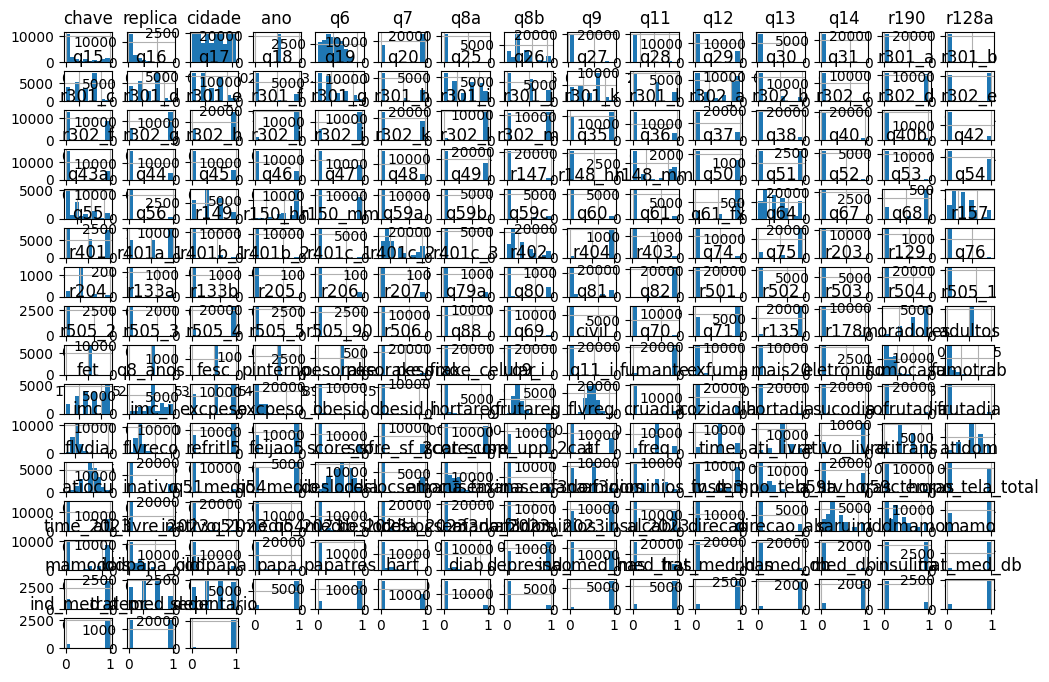

In [ ]:
df.hist(figsize=(12,8))

<Axes: xlabel='sedentario', ylabel='q6'>

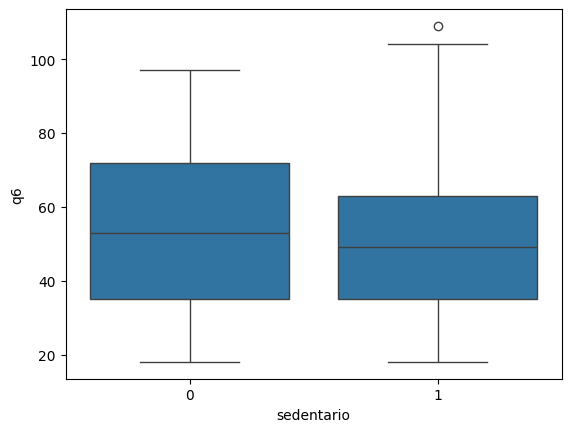

In [ ]:
import seaborn as sns
sns.boxplot(x='sedentario', y='q6', data=df)

Relação entre sedentarismo e variável q6
O gráfico apresenta a distribuição da variável "q6" em relação à classificação de indivíduos sedentários e não sedentários.
Observa-se que:
- A mediana dos valores de "q6" é semelhante entre os dois grupos, com pequenas variações.
- Existe uma dispersão considerável nos dados, indicando variabilidade entre os indivíduos.
- Há presença de possíveis outliers, o que sugere a existência de valores extremos na variável analisada.
Esses resultados indicam que a variável "q6" pode apresentar alguma relação com o comportamento sedentário, mas, isoladamente, pode não ser suficiente para distinguir claramente entre os grupos.
Dessa forma, torna-se importante analisar outras variáveis em conjunto para melhorar a capacidade preditiva dos modelos.

Foram realizadas as seguintes etapas de pré-processamento:

- Tratamento de valores ausentes (NaN), evitando perda de informações relevantes;
- Substituição de valores inválidos (como 888 e 999), que representam dados não informados;
- Ajuste de tipos de dados, quando necessário;
- Preparação das variáveis para aplicação dos modelos de Machine Learning.

Essas etapas são fundamentais para garantir que os modelos aprendam padrões reais dos dados, evitando vieses e erros causados por informações inconsistentes.

In [ ]:
df['sedentario'].value_counts()

,count
sedentario,
1,20833
0,857


In [ ]:
df.describe()

,chave,replica,cidade,ano,q6,q7,q8a,q8b,q9,q11,...,ind_med_has,med_has,trat_med_has,ind_med_db,med_db,insulina,trat_med_db,ind_med_depr,trat_med_depr,sedentario
count,2.169000e+04,21690.000000,21690.000000,21690.0,21690.000000,21690.000000,21690.000000,21272.000000,21690.000000,21690.000000,...,7405.000000,7405.000000,7405.000000,2826.000000,2826.000000,2826.000000,2826.000000,2972.000000,2972.000000,21690.000000
mean,2.841828e+11,19.667404,14.003181,2023.0,49.669617,1.625081,9.266943,3.596183,99.951683,197.024620,...,0.924105,0.845375,0.840918,0.911890,0.819179,0.199575,0.857042,0.861709,0.495626,0.960489
std,3.225600e+11,22.188005,7.798268,0.0,17.827901,0.484113,59.051148,1.881862,136.367189,138.043489,...,0.264847,0.361571,0.365777,0.283506,0.384938,0.399752,0.350092,0.345263,0.500065,0.194812
min,2.104521e+08,1.000000,1.000000,2023.0,18.000000,1.000000,1.000000,1.000000,30.000000,120.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.137964e+10,5.000000,7.000000,2023.0,35.000000,1.000000,5.000000,3.000000,62.000000,158.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000
50%,9.635723e+10,12.000000,14.000000,2023.0,49.000000,2.000000,5.000000,3.000000,72.000000,165.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000
75%,4.991124e+11,27.000000,21.000000,2023.0,64.000000,2.000000,6.000000,4.000000,84.000000,173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,9.999939e+11,157.000000,27.000000,2023.0,109.000000,2.000000,888.000000,8.000000,888.000000,888.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: xlabel='sedentario', ylabel='count'>

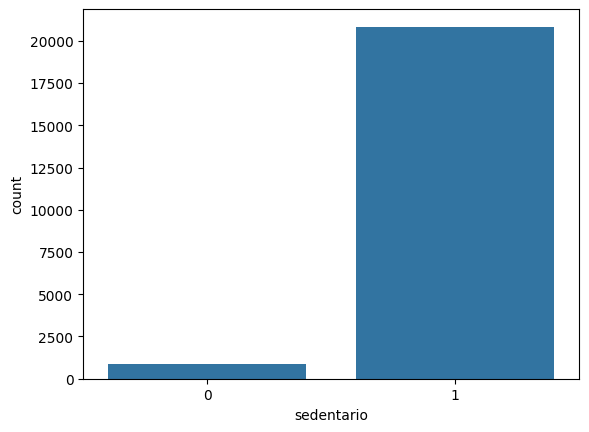

In [ ]:
import seaborn as sns
sns.countplot(x='sedentario', data=df)

<Axes: xlabel='sedentario', ylabel='q6'>

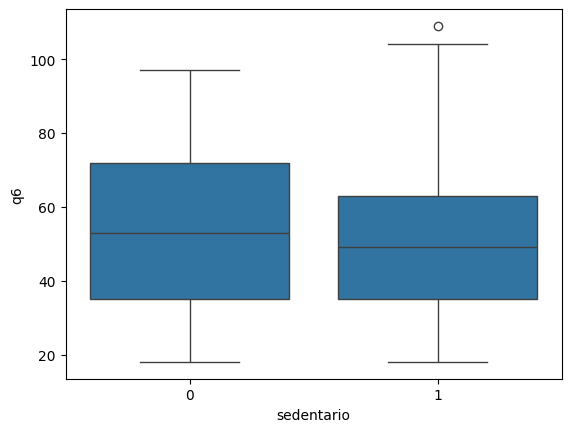

In [ ]:
sns.boxplot(x='sedentario', y='q6', data=df)

In [ ]:
X = df[features]
y = df['sedentario']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
df.replace([888, 999], np.nan, inplace=True)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Garantir que só tem números
X = df[features].select_dtypes(include=[np.number])

# 2. Garantir que não tem NaN
X = X.fillna(X.median())

# 3. Target
y = df['sedentario']

# 4. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Modelo
modelo_lr = LogisticRegression(class_weight='balanced', max_iter=1000)

# 6. Treinar
modelo_lr.fit(X_train, y_train)

# 7. Prever
y_pred = modelo_lr.predict(X_test)

# 8. Avaliar
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.05      0.71      0.09       171
           1       0.97      0.40      0.57      4167

    accuracy                           0.41      4338
   macro avg       0.51      0.56      0.33      4338
weighted avg       0.93      0.41      0.55      4338

[[ 122   49]
 [2503 1664]]


In [ ]:
class_weight={0:2, 1:1}

In [ ]:
df.shape

(21690, 234)

In [ ]:
df.columns

Index(['chave', 'tipo_fone', 'replica', 'cidade', 'ano', 'q6', 'q7', 'q8a',
       'q8b', 'q9',
       ...
       'ind_med_has', 'med_has', 'trat_med_has', 'ind_med_db', 'med_db',
       'insulina', 'trat_med_db', 'ind_med_depr', 'trat_med_depr',
       'sedentario'],
      dtype='object', length=234)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.09      0.01      0.02       171
           1       0.96      1.00      0.98      4167

    accuracy                           0.96      4338
   macro avg       0.53      0.50      0.50      4338
weighted avg       0.93      0.96      0.94      4338

[[   2  169]
 [  20 4147]]


Comparação dos Modelos
Ao comparar os modelos, observa-se que:

- O modelo Dummy apresentou o pior desempenho, servindo apenas como baseline;
- A Regressão Logística apresentou melhora inicial, conseguindo identificar melhor as classes;
- A Árvore de Decisão capturou padrões mais complexos;
- O Random Forest apresentou a maior acurácia geral, porém com forte tendência à classe majoritária.

Isso evidencia a influência do desbalanceamento dos dados no desempenho dos modelos.

#Modelo Final
O modelo escolhido foi o Random Forest, por apresentar o melhor desempenho geral em termos de acurácia e capacidade de capturar padrões complexos.
No entanto, destaca-se que o modelo apresentou dificuldades na identificação da classe minoritária, indicando a necessidade de técnicas adicionais, como balanceamento de dados, para melhorar seu desempenho.
Ainda assim, o modelo se mostrou o mais adequado dentre os avaliados para o problema proposto.

Conclusão

O projeto atingiu o objetivo de desenvolver um modelo capaz de classificar indivíduos como sedentários ou não sedentários com base em dados de estilo de vida. Os resultados demonstraram que, embora modelos mais avançados como o Random Forest apresentem alta acurácia, o desbalanceamento dos dados pode impactar significativamente o desempenho na identificação de classes minoritárias. Como trabalho futuro, recomenda-se a aplicação de técnicas de balanceamento de dados para melhorar a capacidade de generalização do modelo.
Ainda assim, o uso de Machine Learning mostrou-se eficaz na identificação de padrões relacionados ao comportamento sedentário, contribuindo para a análise e compreensão desse problema de saúde pública.